# vgscDL paper figures

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## vgscDL homozygosity and fitness

### Group lay percentages

In [ ]:
# Data
cages = ["A", "B", "C"]
cfp_pos = [338, 513, 448]
cfp_neg = [162, 246, 213]

totals = [p + n for p, n in zip(cfp_pos, cfp_neg)]
percent_pos = [p / t * 100 for p, t in zip(cfp_pos, totals)]
percent_neg = [p / t * 100 for p, t in zip(cfp_neg, totals)]

In [ ]:

# --- Plot ---
plt.figure(figsize=(4, 5))

# Stacked bars (percent scale)
bars_pos = plt.bar(
    cages, percent_pos,
    label=r"vgscKO$^{+}$",
    color="#0B3C8C",
    edgecolor="black",
)
bars_neg = plt.bar(
    cages, percent_neg,
    bottom=percent_pos,
    label=r"vgscKO$^{-}$",
    color="#F4A6A6",
    edgecolor="black",
)

# --- Labels ---
# 1) Percentages above bars (show % CFP+)
for i, pct in enumerate(percent_pos):
    plt.text(i, 100 + 2, f"{pct:.1f}%", ha="center", va="bottom", fontsize=11)

# (Optional) also show total n above bar, a bit higher than the % label
#for i, t in enumerate(totals):
#    plt.text(i, 100 + 12, f"n={t}", ha="center", va="bottom", fontsize=10, color="gray")

# 2) Original counts inside each segment
# Use thresholds so labels don’t collide in very small segments.
inside_thresh = 7  # percent height threshold below which we skip inside label

for i, (pp, pn, p_count, n_count) in enumerate(zip(percent_pos, percent_neg, cfp_pos, cfp_neg)):
    # CFP+ segment count (centered within CFP+ block)
    if pp >= inside_thresh:
        plt.text(i, pp * 0.5, f"{p_count}", ha="center", va="center",
                 fontsize=11, color="white")  # white stands out on blue

    # CFP− segment count (centered within CFP− block, offset by bottom=pp)
    if pn >= inside_thresh:
        plt.text(i, pp + pn * 0.5, f"{n_count}", ha="center", va="center",
                 fontsize=11, color="black")

# Axes and style
plt.ylabel("Percentage of larvae (%)", fontsize=11)
plt.xlabel("Cage (observed)", fontsize=11)
plt.ylim(0, 110)               # headroom for labels
plt.yticks([0, 20, 40, 60, 80, 100])

# Clean spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout()
#plt.show()
plt.savefig("GroupLayPercentages_with_counts.svg")

In [ ]:
### Same but for expected proportions - to add together to last graph in biorender

# Data
cages = ["Homs", "NoHoms"]
cfp_pos = [750, 666]
cfp_neg = [250, 333]

totals = [p + n for p, n in zip(cfp_pos, cfp_neg)]
percent_pos = [p / t * 100 for p, t in zip(cfp_pos, totals)]
percent_neg = [p / t * 100 for p, t in zip(cfp_neg, totals)]

# --- Plot ---
plt.figure(figsize=(3, 5))

# Stacked bars (percent scale)
bars_pos = plt.bar(
    cages, percent_pos,
    label=r"vgscKO$^{+}$",
    color="#0B3C8C",
    edgecolor="black",
)
bars_neg = plt.bar(
    cages, percent_neg,
    bottom=percent_pos,
    label=r"vgscKO$^{-}$",
    color="#F4A6A6",
    edgecolor="black",
)

# --- Labels ---
# 1) Percentages above bars (show % CFP+)
for i, pct in enumerate(percent_pos):
    plt.text(i, 100 + 2, f"{pct:.1f}%", ha="center", va="bottom", fontsize=11)

# (Optional) also show total n above bar, a bit higher than the % label
#for i, t in enumerate(totals):
#    plt.text(i, 100 + 12, f"n={t}", ha="center", va="bottom", fontsize=10, color="gray")

# Axes and style
plt.ylabel("Percentage of larvae (%)", fontsize=11)
plt.xlabel("Expected", fontsize=11)
plt.ylim(0, 110)               # headroom for labels
plt.yticks([0, 20, 40, 60, 80, 100])

# Clean spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout()
#plt.show()
plt.savefig("GroupLayPercentages_expected.svg")

## Fertility/fecundity

In [ ]:
df = pd.read_csv("HatchData.csv")
df

In [ ]:
cols = ["Eggs", "Genotype", "Larvae"]
# Remove any with no eggs or not recorded genotypes (will be reported in manuscript)
df1 = df[~df[cols].isin([0, "NR", "NA"]).any(axis=1)]
#len(df)
len(df1)


In [ ]:
df2 = df1.dropna(subset=["Genotype"])
len(df2)

### Violin plot of eggs laid

In [ ]:

pal = {"vgscKO": "#3DA4E0", "WT":"#F4A6A6"}

plt.figure(figsize=(4,5)) 

# Violin without inner marks
sns.violinplot(
    x="vgscKOParent",
    y="Eggs",
    hue="Genotype",
    data=df2,
    cut=0,
    split=True,
    palette={"vgscKO": "#0072B2", "WT": "#F4A6A6"},
    width=0.6,
    inner=None
)

# Overlay boxplot with controlled width
sns.boxplot(
    x="vgscKOParent",
    y="Eggs",
    hue="Genotype",
    data=df2,
    width=0.18,             # make the middle “bars/boxes” bigger by increasing this
    dodge=True,             # aligns with split halves
    showcaps=False,
    showfliers=False,
    boxprops={"facecolor": "#FFFFFF", "edgecolor": "black", "linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.4},
    whiskerprops={"linewidth": 1.0, "color": "black"}
)

# Remove the duplicated legend from the overlay
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend().remove()  # remove the automatic one
# Optionally rebuild a clean legend from the first two (violin) entries
# plt.legend(handles[:2], labels[:2], frameon=False, loc="upper right")


plt.ylabel("Eggs laid")
plt.xlabel("vgscKO parent")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#plt.legend(frameon=False, bbox_to_anchor = [0.9,1])

plt.tight_layout()

#plt.show()
plt.savefig("FecundityEggsV.svg")
plt.savefig("FecundityEggsV.png")

### Violin plot of total larvae produced

In [ ]:
df2["Larvae"] = pd.to_numeric(df2["Larvae"], errors="coerce")


In [ ]:

pal = {"vgscKO": "#3DA4E0", "WT":"#F4A6A6"}

plt.figure(figsize=(4,5)) 

# Violin without inner marks
sns.violinplot(
    x="vgscKOParent",
    y="Larvae",
    hue="Genotype",
    data=df2,
    cut=0,
    split=True,
    palette={"vgscKO": "#0072B2", "WT": "#F4A6A6"},
    width=0.6,
    inner=None
)

# Overlay boxplot with controlled width
sns.boxplot(
    x="vgscKOParent",
    y="Larvae",
    hue="Genotype",
    data=df2,
    width=0.18,             # make the middle “bars/boxes” bigger by increasing this
    dodge=True,             # aligns with split halves
    showcaps=False,
    showfliers=False,
    boxprops={"facecolor": "#FFFFFF", "edgecolor": "black", "linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.4},
    whiskerprops={"linewidth": 1.0, "color": "black"}
)

# Remove the duplicated legend from the overlay
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend().remove()  # remove the automatic one
# Optionally rebuild a clean legend from the first two (violin) entries
# plt.legend(handles[:2], labels[:2], frameon=False, loc="upper right")


plt.ylabel("Larvae hatched")
plt.xlabel("vgscKO parent")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#plt.legend(frameon=False, bbox_to_anchor = [0.9,1])

plt.tight_layout()

#plt.show()
plt.savefig("FecundityLarvaeV.svg")
plt.savefig("FecundityLarvaeV.png")

### Violin plot of percentage of eggs hatched

In [ ]:

pal = {"vgscKO": "#3DA4E0", "WT":"#F4A6A6"}

plt.figure(figsize=(4,5)) 

sns.violinplot(
    x="vgscKOParent",
    y="Hatch",
    hue="Genotype",
    cut=0,
    data=df2,
    split=True,
    palette={"vgscKO": "#0072B2", "WT": "#F4A6A6"},
    width=0.6,
    inner=None
)

sns.boxplot(
    x="vgscKOParent",
    y="Hatch",
    hue="Genotype",
    data=df2,
    width=0.18,
    dodge=True,
    showcaps=False,
    showfliers=False,
    boxprops={"facecolor": "#FFFFFF", "edgecolor": "black", "linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.4},
    whiskerprops={"linewidth": 1.0, "color": "black"}
)


handles, labels = plt.gca().get_legend_handles_labels()
plt.legend().remove()

plt.ylabel("Percentage hatched")
plt.xlabel("vgscKO parent")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

#plt.show()
plt.savefig("FecundityPercV.svg")
plt.savefig("FecundityPercV.png")

# Single deposition het/hom pie charts

In [ ]:
# Data
vgscDLParent = ["Male", "Female"]
Heterozygotes = [26,70]
Homozygotes = [0,0]

In [ ]:
categories = ["Heterozygotes", "Homozygotes"]
colors = ["#0B3C8C", "#F4A6A6"]  # blue for Hets, red for Homs


fig, axes = plt.subplots(1, 2, figsize=(9, 5))

for i, sex in enumerate(vgscDLParent):
    ax = axes[i]
    values = [Heterozygotes[i], Homozygotes[i]]
    total = sum(values)

    if total > 0 and any(v > 0 for v in values):
        wedges, texts, autotexts = ax.pie(
            values,
            labels=categories,
            colors=colors,
            startangle=90,
            autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100*total))})" if pct > 0 else "",
            textprops={"color": "white", "fontsize": 14},
            wedgeprops={"linewidth": 1, "edgecolor": "white"},
        )
        ax.legend(wedges, categories, title="Genotype",
                  loc="lower center", bbox_to_anchor=(0.5, -0.15),
                  ncol=2, frameon=False, fontsize=14, title_fontsize=16)
    else:
        # In case a sex had no counts at all
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)
        ax.set_aspect('equal')
        circle = plt.Circle((0, 0), 0.99, color="#dddddd", fill=False, linewidth=1)
        ax.add_artist(circle)

    ax.set_title(f"{sex} (n={total})", fontsize=14)
    ax.axis('equal')

plt.tight_layout()
plt.savefig("vgsc_sexwise_pies.png", dpi=300)

# Also save as two separate image files (one per sex)
for i, sex in enumerate(vgscDLParent):
    fig_i, ax_i = plt.subplots(figsize=(4, 4))
    values = [Hets[i], Homs[i]]
    total = sum(values)
    if total > 0 and any(v > 0 for v in values):
        ax_i.pie(
            values,
            labels=categories,
            colors=colors,
            startangle=90,
            autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100*total))})" if pct > 0 else "",
            textprops={"color": "white", "fontsize": 15},
            wedgeprops={"linewidth": 1, "edgecolor": "white"},
        )
    else:
        ax_i.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)
        ax_i.set_aspect('equal')
        circle = plt.Circle((0, 0), 0.99, color="#dddddd", fill=False, linewidth=1)
        ax_i.add_artist(circle)
    ax_i.set_title(f"{sex} (n={total})", fontsize=12)
    ax_i.axis('equal')
    plt.tight_layout()
    fig_i.savefig(f"vgsc_{sex.lower()}_pie.png", dpi=300)

## LC50/LC95 bar plot for insecticides

In [ ]:
dataDelt = {
    "Level": ["LC50","LC50","LC99","LC99"],
    "Genotype": ["vgscKO$^{+}$","vgscKO$^{-}$","vgscKO$^{+}$","vgscKO$^{-}$"],
    "Dose": [0.77, 0.35, 11.59, 3.97],
    "SE": [1.159, 1.136, 1.387, 1.362]
}

df = pd.DataFrame(dataDelt)

levels = df["Level"].unique()
genotypes = df["Genotype"].unique()

colours = {"vgscKO$^{+}$": "#0B3C8C",
          "vgscKO$^{-}$": "#F4A6A6"}


# Plot
fig, ax = plt.subplots(figsize=(3, 4))

x = np.arange(len(levels)) * 0.5
bar_width = 0.2

for i, genotype in enumerate(genotypes):
    subset = df[df["Genotype"] == genotype]
    ax.bar(
        x + (i - 0.5)*bar_width,
        subset["Dose"],
        bar_width,
        yerr=subset["SE"],
        color=colours[genotype],
        capsize=4,
        label=genotype
    )



ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_ylabel("Deltamethrin dose (µg/ml)")

plt.tight_layout()
#plt.show()

plt.savefig("DeltaLCBars.svg")
plt.savefig("DeltaLCBars.png")

In [ ]:
dataDDT = {
    "Level": ["LC50","LC50","LC99","LC99"],
    "Genotype": ["vgscKO$^{+}$","vgscKO$^{-}$",
                 "vgscKO$^{+}$","vgscKO$^{-}$"],
    "Dose": [58.29, 15.53, 12120.66, 838.98],
    "SE": [1.387, 1.166, 3.457, 1.566]
}

df = pd.DataFrame(dataDDT)

levels = ["LC50", "LC99"]
genotypes = ["vgscKO$^{+}$", "vgscKO$^{-}$"]

# Build full grid (prevents shape mismatches)
full = (
    df.set_index(["Level","Genotype"])
      .reindex(pd.MultiIndex.from_product([levels, genotypes],
               names=["Level","Genotype"]))
      .reset_index()
)


x = np.arange(len(levels)) * 0.5
bar_width = 0.2
tightness = 1

colours = {
    "vgscKO$^{+}$": "#0B3C8C",
    "vgscKO$^{-}$": "#F4A6A6"
}

fig, ax = plt.subplots(figsize=(3, 4))

for i, genotype in enumerate(genotypes):
    g = full[full["Genotype"] == genotype].set_index("Level")

    xpos = x + (i - 0.5)*bar_width*tightness

    ax.bar(
        xpos,
        g["Dose"],
        bar_width,
        yerr=g["SE"],
        capsize=4,
        color=colours[genotype],
        label=genotype
    )

ax.set_yscale("log")


ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_ylabel("DDT dose µg/ml (log scale)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
#plt.show()

plt.savefig("DDTLCBars.svg")
plt.savefig("DDTLCBars.png")

## Supplementary: screening timing assay

In [2]:
df = pd.read_csv("ScreenTime.csv")
df

,Time_h,Fluorescence,PCR,Total,Classification,Correct
0,1hr,CFP+,CFP+,42,True positives,Yes
1,1hr,CFP+,CFP-,0,False positives,No
2,1hr,CFP+,Inconclusive,5,Inconclusive,No
3,1hr,CFP-,CFP+,3,False negatives,No
4,1hr,CFP-,CFP-,42,True negatives,Yes
5,1hr,CFP-,Inconclusive,2,Inconclusive,No
6,6hr,CFP+,CFP+,46,True positives,Yes
7,6hr,CFP+,CFP-,0,False positives,No
8,6hr,CFP+,Inconclusive,1,Inconclusive,No
9,6hr,CFP-,CFP+,0,False negatives,No


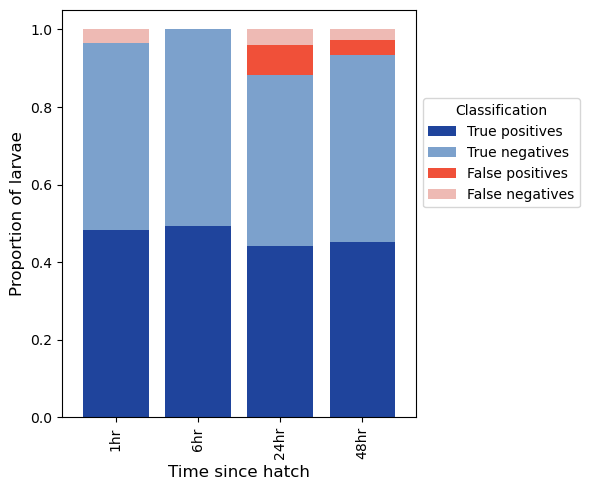

In [3]:
df = df[df["Classification"] != "Inconclusive"]

# Pivot for stacked plotting
pivot = df.pivot(index="Time_h", columns="Classification", values="Total")
time_order = ["1hr", "6hr", "24hr", "48hr"]
pivot = pivot.reindex(time_order)

class_order = [
    "True positives",
    "True negatives",
    "False positives",
    "False negatives"
]
pivot = pivot[class_order]

colours = {
    "True positives": "#1F449C",
    "True negatives": "#7CA1CC",
    "False positives": "#F05039",
    "False negatives": "#EEBAB4",
}

colour_list = [colours[c] for c in pivot.columns]

pivot_prop = pivot.div(pivot.sum(axis=1), axis=0)

# Plot
pivot_prop.plot(
    kind="bar",
    stacked=True,
    width=0.8,
    figsize=(6,5),
    color=colour_list)

#plt.ylim(0, 100)
#plt.yticks([0, 20, 40, 60, 80, 100])


plt.xlabel("Time since hatch", fontsize=12)
plt.ylabel("Proportion of larvae", fontsize = 12)
plt.legend(title="Classification", bbox_to_anchor=(1,0.8))
plt.tight_layout()

#plt.show()

plt.savefig("ScreenTime.svg")
plt.savefig("ScreenTime.png")